# Part 1: Set Up Project

This notebook contains the code and notes for our CS 178 group project. The project investigates several classification methods on the Fashion-MNIST dataset, which is an image classification dataset containing grayscale clothing images. The goal is to compare simple and moderately more advanced machine learning classifiers using a reproducible workflow similar to previous CS 178 homework assignments.

The project is organized so that the first half of the notebook establishes the dataset, exploratory analysis, train/validation/test split, helper functions, and baseline classifiers. The remaining sections are included as structured placeholders for the rest of the group to complete. This makes the notebook usable as both a working project file and a handoff document.

The final report must include the required project sections: Summary, Data Description, Classifiers, Experimental Setup, Experimental Results, Insights, and Contributions. This notebook is structured to generate the information, figures, and results needed for those sections.

### Project title

**An Investigation of Classification Methods for Fashion-MNIST**

### Dataset

We use Fashion-MNIST because it is one of the approved project datasets and it matches the image-classification workflow used in prior assignments. Each example is a 28 x 28 grayscale image, flattened into 784 numerical features. The task is to predict one of 10 clothing categories.

### Division of work

| Person | Main responsibility |
|---|---|
| Jacob Peters | Set up notebook, load data, explore data, create split, write helper functions, train Nearest Centroid and k-Nearest Neighbors baselines |
| Member A | Complete Logistic Regression and Decision Tree experiments |
| Member B | Complete MLP Classifier and final test evaluation |
| Member C | Complete confusion matrix, error analysis, report notes, final insights, and final writeup |

### Important project rule

The test set should not be used during model development or hyperparameter tuning. Models should be compared using the validation set first. The test set should only be used once near the end of the project for final evaluation.

In [1]:
# Optional: disable IPython history saving if the environment has a read-only history database.
# This does not affect the project code or results.
%config HistoryManager.enabled = False

# Set up imports for the full project.
# These imports follow the same general NumPy, pandas, matplotlib, and scikit-learn workflow
# used in previous CS 178 homework notebooks.

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import warnings
import os
import gzip
import struct
import urllib.request

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.preprocessing import StandardScaler

# Keep notebook output cleaner.
warnings.filterwarnings("ignore")

# Set a fixed random seed so that data splitting and repeated experiments are reproducible.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Set team member names here.
# If a group member changes, update the name here once instead of changing it throughout the notebook.

MEMBER_X = "Jacob Peters"
MEMBER_A = "Member A"
MEMBER_B = "Member B"
MEMBER_C = "Member C"

# Set global folder paths used throughout the notebook.
DATA_DIR = "data/fashion-mnist"
FIGURES_DIR = "figures"

# Create project folders if they do not already exist.
# Later notebook sections should use these folders instead of creating new ones independently.
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Make plots display clearly in the notebook.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["image.interpolation"] = "nearest"

print("Set up complete.")
print("Random seed:", RANDOM_SEED)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Team member variables:")
print("MEMBER_X:", MEMBER_X)
print("MEMBER_A:", MEMBER_A)
print("MEMBER_B:", MEMBER_B)
print("MEMBER_C:", MEMBER_C)

Set up complete.
Random seed: 42
Data directory: data/fashion-mnist
Figures directory: figures
Team member variables:
MEMBER_X: Jacob Peters
MEMBER_A: Member A
MEMBER_B: Member B
MEMBER_C: Member C


#### Part 1: Summary

This setup section establishes the overall project direction, dataset choice, division of labor, and software environment. It supports the final report by clearly identifying the project as a Fashion-MNIST classification study and documenting that the work uses a reproducible scikit-learn-based workflow. The imports also prepare the notebook for all required project components, including data exploration, classifier training, validation-based model selection, final test evaluation, confusion matrices, and error analysis.

For the final PDF report, this section mainly contributes to the **Summary**, **Experimental Setup**, and **Contributions** sections. The team-role table helps document how work is divided across group members, while the fixed random seed supports reproducibility in the experimental methodology.

# Part 2: Load Data Set

In this section, we load the Fashion-MNIST dataset into the notebook. Fashion-MNIST is the dataset selected for this project because it is an approved image classification dataset and fits naturally with the scikit-learn workflow used in previous assignments. Each example is a grayscale image of a clothing item. The original image is 28 x 28 pixels, but when loaded through OpenML, each image is represented as a flattened vector with 784 numerical features.

This section creates the main variables that will be used throughout the rest of the project:

- `fashion_mnist`: the full dataset object returned by OpenML
- `X`: the input data, where each row is one image
- `y`: the class label for each image
- `class_names`: readable names for the 10 clothing categories

The pixel values are scaled from their original range of 0 to 255 into the range 0 to 1. This keeps the data in a standard numerical range and is especially helpful for distance-based classifiers such as Nearest Centroid and k-Nearest Neighbors.

This section does not split the data yet. The train, validation, and test split will be created later in a separate section so that the experimental setup is clearly documented.

In [2]:
# Load Fashion-MNIST from the official GitHub source.
# This avoids OpenML issues while keeping the rest of the project in NumPy / scikit-learn format.
# The files are downloaded into DATA_DIR, which was created in the Set up section.

BASE_URL = "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion"

files = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz"
}

# Download each file only if it does not already exist locally.
for filename in files.values():
    filepath = os.path.join(DATA_DIR, filename)
    
    if not os.path.exists(filepath):
        print("Downloading", filename)
        urllib.request.urlretrieve(BASE_URL + "/" + filename, filepath)

def load_images(filepath):
    with gzip.open(filepath, "rb") as file:
        magic, num_images, rows, cols = struct.unpack(">IIII", file.read(16))
        images = np.frombuffer(file.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
    return images

def load_labels(filepath):
    with gzip.open(filepath, "rb") as file:
        magic, num_labels = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels

# Load the original official train and test files.
X_train_original = load_images(os.path.join(DATA_DIR, files["train_images"]))
y_train_original = load_labels(os.path.join(DATA_DIR, files["train_labels"]))

X_test_original = load_images(os.path.join(DATA_DIR, files["test_images"]))
y_test_original = load_labels(os.path.join(DATA_DIR, files["test_labels"]))

# Combine the official train and test files into one full dataset for general exploration.
# The actual train / validation / test split will be handled in a later section.
X = np.vstack((X_train_original, X_test_original)).astype(np.float32)
y = np.concatenate((y_train_original, y_test_original)).astype(int)

# Scale pixel values from [0, 255] to [0, 1].
X = X / 255.0

# Define readable class names for the 10 Fashion-MNIST categories.
class_names = np.array([
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
])

# Print basic dataset information to confirm that the data loaded correctly.
print("Dataset loaded successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of examples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))
print("Class labels:", np.unique(y))
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Dataset loaded successfully.
X shape: (70000, 784)
y shape: (70000,)
Number of examples: 70000
Number of features: 784
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]
Minimum pixel value: 0.0
Maximum pixel value: 1.0


#### Part 2: Summary

This section contributes directly to the **Data Description** portion of the final PDF report. It verifies that the project uses Fashion-MNIST, identifies the number of examples, number of features, number of classes, and the format of each input image. It also documents the basic preprocessing step of scaling pixel values to the range 0 to 1.

The variables created here will be used by every later section of the notebook, including data exploration, train/validation/test splitting, classifier training, validation comparison, final test evaluation, and error analysis.

# Part 3: Data Exploration

In this section, we perform initial exploration of the Fashion-MNIST dataset. The purpose of this section is to better understand the data before training any machine learning models. This also directly supports the final report requirement that the Data Description section include dataset exploration and at least one figure.

We create two simple visualizations:

1. A grid of sample images, showing one example from each of the 10 Fashion-MNIST classes.
2. A class distribution bar chart, showing how many examples belong to each class.

The sample image grid helps verify that the images loaded correctly and gives a visual overview of the classification task. The class distribution plot helps determine whether the dataset is balanced across classes. If the classes are balanced, then accuracy is a reasonable primary evaluation metric. If the classes were highly imbalanced, then we would need to rely more heavily on metrics like precision, recall, or macro-F1.

The figures are displayed inside the notebook and also saved in a local `figures/` directory. Each time this cell is run, the saved image files are overwritten so that the files always reflect the most recent version of the code.

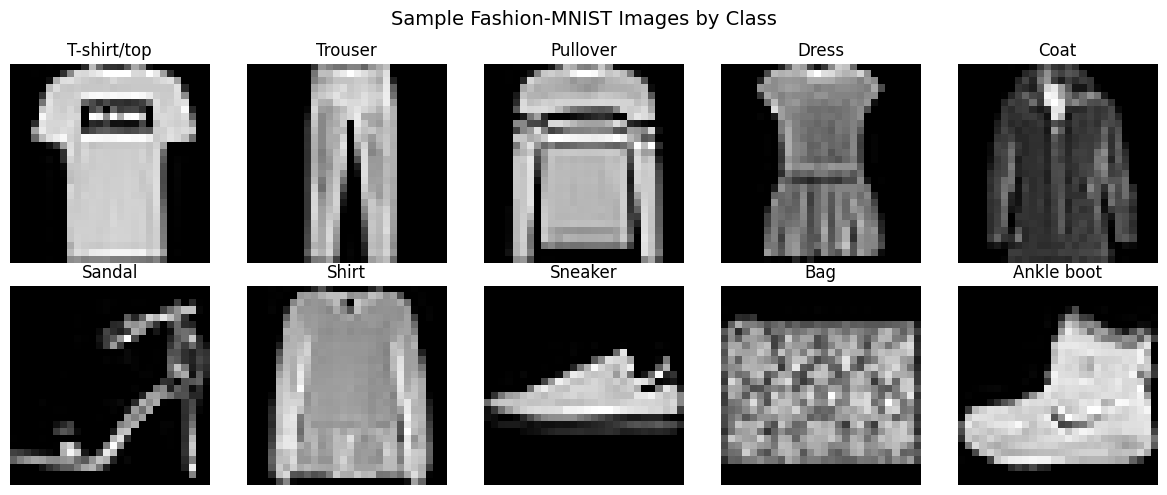

,label,class_name,count,percentage
0,0,T-shirt/top,7000,10.0
1,1,Trouser,7000,10.0
2,2,Pullover,7000,10.0
3,3,Dress,7000,10.0
4,4,Coat,7000,10.0
5,5,Sandal,7000,10.0
6,6,Shirt,7000,10.0
7,7,Sneaker,7000,10.0
8,8,Bag,7000,10.0
9,9,Ankle boot,7000,10.0


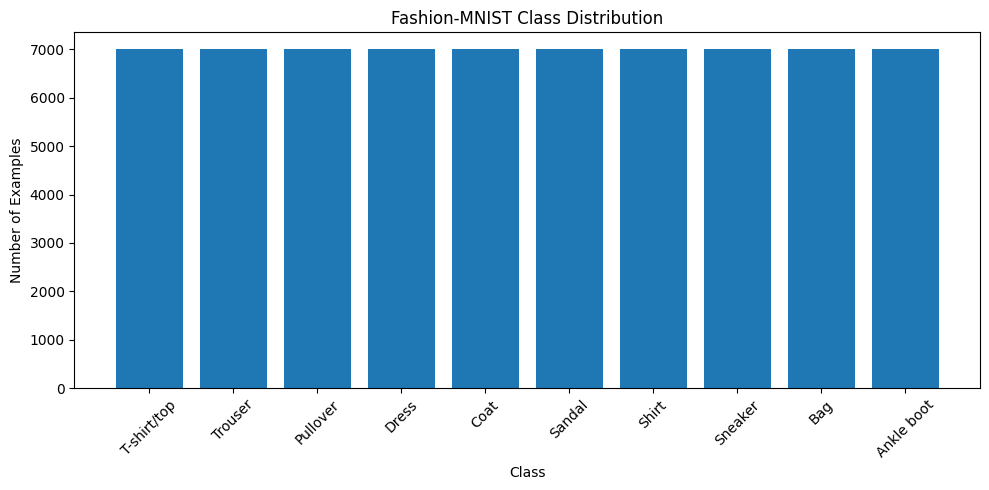

In [3]:
# ------------------------------------------------------------
# Figure 1: Display one sample image from each Fashion-MNIST class.
# ------------------------------------------------------------

figure, axes = plt.subplots(2, 5, figsize=(12, 5))
figure.suptitle("Sample Fashion-MNIST Images by Class", fontsize=14)

for label in range(10):
    # Find the first example in the dataset with this class label.
    index = np.where(y == label)[0][0]
    
    # Reshape the flattened 784-feature vector back into a 28 x 28 image.
    image = X[index].reshape(28, 28)
    
    # Choose the correct subplot location.
    row = label // 5
    col = label % 5
    
    axes[row, col].imshow(image)
    axes[row, col].set_title(class_names[label])
    axes[row, col].axis("off")

plt.tight_layout()

# Save the figure. This overwrites the existing file if it already exists.
plt.savefig(os.path.join(FIGURES_DIR, "sample_images.png"), bbox_inches="tight", dpi=300)

plt.show()


# ------------------------------------------------------------
# Table: Count how many examples are in each class.
# ------------------------------------------------------------

class_counts = pd.Series(y).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "label": class_counts.index,
    "class_name": class_names[class_counts.index],
    "count": class_counts.values,
    "percentage": class_counts.values / len(y) * 100
})

display(class_distribution)


# ------------------------------------------------------------
# Figure 2: Plot the class distribution.
# ------------------------------------------------------------

figure, axes = plt.subplots(1, 1, figsize=(10, 5))

axes.bar(class_distribution["class_name"], class_distribution["count"])
axes.set_title("Fashion-MNIST Class Distribution")
axes.set_xlabel("Class")
axes.set_ylabel("Number of Examples")
axes.tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save the figure. This overwrites the existing file if it already exists.
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), bbox_inches="tight", dpi=300)

plt.show()

#### Part 3: Summary

This section contributes directly to the **Data Description** section of the final PDF report. The sample image grid provides a visual example of the 10 Fashion-MNIST classes, while the class distribution table and bar chart show whether the dataset is balanced across labels.

These outputs can be used in the final report to explain the structure of the dataset, describe the classification task, and justify using accuracy as a main evaluation metric. The saved figures in the `figures/` directory can also be inserted directly into the final PDF report.

# Part 4: Split Data into Training, Validation, and Test

In this section, we divide the Fashion-MNIST data into separate training, validation, and test sets. This is one of the most important parts of the project because it defines how model performance will be measured fairly.

Fashion-MNIST comes with an official training set of 60,000 examples and an official test set of 10,000 examples. We reserve the official test set for final evaluation only. This means the test set should not be used while choosing models, tuning hyperparameters, or deciding which classifier is best during development.

The official 60,000-example training set is split into:

- 48,000 training examples
- 12,000 validation examples

The validation set will be used to compare models and tune hyperparameters. The final test set will only be used later, after all model choices have been made.

We use a stratified split so that each class remains balanced in the training and validation sets. Since Fashion-MNIST has 10 balanced classes, this should result in approximately 4,800 training examples and 1,200 validation examples per class.

In [4]:
# Start from the official Fashion-MNIST train and test files loaded earlier.
# X_train_original and X_test_original are currently unscaled, so we scale them here.

X_dev = X_train_original.astype(np.float32) / 255.0
y_dev = y_train_original.astype(int)

X_test = X_test_original.astype(np.float32) / 255.0
y_test = y_test_original.astype(int)

# Split the official 60,000-example training set into training and validation sets.
# The test set remains untouched for final evaluation only.

X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_dev
)

# Create a summary table showing the size of each split.

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Test"],
    "number_of_examples": [len(X_train), len(X_valid), len(X_test)],
    "percentage_of_total": [
        len(X_train) / (len(X_train) + len(X_valid) + len(X_test)) * 100,
        len(X_valid) / (len(X_train) + len(X_valid) + len(X_test)) * 100,
        len(X_test) / (len(X_train) + len(X_valid) + len(X_test)) * 100
    ]
})

display(split_summary)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Verify class balance in each split.

train_class_counts = pd.Series(y_train).value_counts().sort_index()
valid_class_counts = pd.Series(y_valid).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

split_class_distribution = pd.DataFrame({
    "label": np.arange(10),
    "class_name": class_names,
    "train_count": train_class_counts.values,
    "valid_count": valid_class_counts.values,
    "test_count": test_class_counts.values
})

display(split_class_distribution)

,split,number_of_examples,percentage_of_total
0,Training,48000,68.571429
1,Validation,12000,17.142857
2,Test,10000,14.285714


Training set shape: (48000, 784) (48000,)
Validation set shape: (12000, 784) (12000,)
Test set shape: (10000, 784) (10000,)


,label,class_name,train_count,valid_count,test_count
0,0,T-shirt/top,4800,1200,1000
1,1,Trouser,4800,1200,1000
2,2,Pullover,4800,1200,1000
3,3,Dress,4800,1200,1000
4,4,Coat,4800,1200,1000
5,5,Sandal,4800,1200,1000
6,6,Shirt,4800,1200,1000
7,7,Sneaker,4800,1200,1000
8,8,Bag,4800,1200,1000
9,9,Ankle boot,4800,1200,1000


#### Part 4: Summary

This section contributes directly to the **Experimental Setup** section of the final PDF report. It documents how the data was partitioned and explains how the project avoids evaluating models unfairly during development.

The project uses the official Fashion-MNIST test set as the final held-out test set. The official training data is split into training and validation sets using a fixed random seed and stratified sampling. The training set will be used to fit models, the validation set will be used to select hyperparameters, and the test set will be used only once for final evaluation.

This split makes the project reproducible and supports a fair comparison between classifiers.

# Part 5: Helper Functions for Model Evaluation

In this section, we define small helper functions that will be reused throughout the rest of the notebook. The purpose of this section is to make the model evaluation process consistent across all classifiers.

Instead of having each group member calculate accuracy, error rate, and validation results in slightly different ways, these functions create one shared evaluation workflow. This matters because the final project report needs to compare multiple classifiers fairly using the same methodology.

The helper functions in this section will be used for:

- Model 1: Nearest Centroid
- Model 2: k-Nearest Neighbors
- Model 3: Logistic Regression
- Model 4: Decision Tree
- Model 5: MLP Classifier
- Final test evaluation

We also initialize a shared list called `validation_results`. Each model section should append its training and validation results to this list. Later, the results will be converted into a pandas DataFrame for comparison, plotting, and final report writing.

In [5]:
# Compute classification accuracy.
# Accuracy is the proportion of examples classified correctly.

def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


# Compute classification error rate.
# Error rate is the proportion of examples classified incorrectly.

def compute_error_rate(y_true, y_pred):
    return 1 - compute_accuracy(y_true, y_pred)


# Evaluate a fitted classifier on both the training set and validation set.
# This function assumes the classifier has already been trained with .fit().

def evaluate_classifier(classifier, X_train, y_train, X_valid, y_valid):
    train_predictions = classifier.predict(X_train)
    valid_predictions = classifier.predict(X_valid)
    
    train_accuracy = compute_accuracy(y_train, train_predictions)
    valid_accuracy = compute_accuracy(y_valid, valid_predictions)
    
    train_error = compute_error_rate(y_train, train_predictions)
    valid_error = compute_error_rate(y_valid, valid_predictions)
    
    return {
        "train_accuracy": train_accuracy,
        "valid_accuracy": valid_accuracy,
        "train_error": train_error,
        "valid_error": valid_error
    }


# Add one model result to a shared results list.
# This keeps the result format consistent across all model sections.

def add_result(results_list, model_name, hyperparameters, results, software, owner):
    results_list.append({
        "model": model_name,
        "hyperparameters": hyperparameters,
        "train_accuracy": results["train_accuracy"],
        "valid_accuracy": results["valid_accuracy"],
        "train_error": results["train_error"],
        "valid_error": results["valid_error"],
        "software": software,
        "owner": owner
    })


# This list will store validation results for all models.
# Each later model section should append its results to this list.

validation_results = []

print("Helper functions created.")
print("validation_results list initialized.")

Helper functions created.
validation_results list initialized.


#### Part 5: Summary

This section contributes to the **Experimental Setup** section of the final PDF report. It documents that all classifiers are evaluated using the same reusable procedure, which makes the experiment more consistent and reproducible.

The helper functions define how accuracy and error rate are calculated, how each classifier is evaluated on training and validation data, and how results are stored for later comparison. This structure supports the final **Experimental Results** section because every model will produce results in the same format.

# Part 6, Model 1: Nearest Centroid

In this section, we train and evaluate **Model 1: Nearest Centroid**. This is the simplest classifier in the project and serves as our first baseline model.

Nearest Centroid works by calculating the average training example for each class. For Fashion-MNIST, this means the model calculates an average image for each clothing category. When the model sees a new image, it predicts the class whose average image is closest to that new image in feature space.

This model is useful because it is simple, fast, and easy to interpret. It gives us a baseline level of performance that later models should try to improve on. Since Nearest Centroid has no major hyperparameters in our basic setup, this section only trains one version of the model.

This section also establishes the required structure that the later model sections should follow. Each model section should:

1. Create and train the classifier.
2. Evaluate the classifier on the training and validation sets.
3. Store the best model object in a clearly named variable.
4. Store the best hyperparameter description in a clearly named variable.
5. Store the best validation results in a clearly named variable.
6. Add the result to the shared `validation_results` list.
7. Display a model-specific results table.

Following this structure is important because later parts of the notebook, especially **Part 11: Model Comparison** and **Part 12: Final Test Evaluation**, will rely on consistent variable names and result formats across all five models.

The test set is not used in this section. The test set remains reserved for final evaluation only.

In [6]:
# ------------------------------------------------------------
# Model 1: Nearest Centroid
# Owner: MEMBER_X
# ------------------------------------------------------------
#
# IMPORTANT TEMPLATE FOR ALL MODEL SECTIONS:
#
# Each model section should leave behind:
# 1. best_<model_name>_model
# 2. best_<model_name>_results
# 3. best_<model_name>_hyperparameters
# 4. <model_name>_results_df
#
# Each model section should also append its best validation result
# to the shared validation_results list using add_result().
#
# This structure allows Part 11: Model Comparison and
# Part 12: Final Test Evaluation to work smoothly later.

# Step 1: Create the classifier.
nearest_centroid_model = NearestCentroid()

# Step 2: Train the classifier using only the training data.
nearest_centroid_model.fit(X_train, y_train)

# Step 3: Evaluate the trained classifier on training and validation data.
nearest_centroid_results = evaluate_classifier(
    nearest_centroid_model,
    X_train,
    y_train,
    X_valid,
    y_valid
)

# Step 4: Since Nearest Centroid has no hyperparameter tuning here,
# this single trained model is automatically the best Nearest Centroid model.
best_nearest_centroid_model = nearest_centroid_model
best_nearest_centroid_results = nearest_centroid_results
best_nearest_centroid_hyperparameters = "none"

# Step 5: Add this model's result to the shared validation_results list.
add_result(
    validation_results,
    model_name="Model 1: Nearest Centroid",
    hyperparameters=best_nearest_centroid_hyperparameters,
    results=best_nearest_centroid_results,
    software="scikit-learn",
    owner=MEMBER_X
)

# Step 6: Create a local results table for this model section.
nearest_centroid_results_df = pd.DataFrame([
    {
        "model": "Model 1: Nearest Centroid",
        "hyperparameters": best_nearest_centroid_hyperparameters,
        "train_accuracy": best_nearest_centroid_results["train_accuracy"],
        "valid_accuracy": best_nearest_centroid_results["valid_accuracy"],
        "train_error": best_nearest_centroid_results["train_error"],
        "valid_error": best_nearest_centroid_results["valid_error"],
        "software": "scikit-learn",
        "owner": MEMBER_X
    }
])

# Step 7: Display the results for this model.
display(nearest_centroid_results_df)

,model,hyperparameters,train_accuracy,valid_accuracy,train_error,valid_error,software,owner
0,Model 1: Nearest Centroid,none,0.684438,0.690917,0.315562,0.309083,scikit-learn,Jacob Peters


#### Part 6: Summary

This section contributes to the **Classifiers**, **Experimental Setup**, and **Experimental Results** sections of the final PDF report.

For the **Classifiers** section, Nearest Centroid can be described as a simple baseline classifier that assigns each image to the class with the closest average training image. Since this basic version of Nearest Centroid does not require hyperparameter tuning, its hyperparameters can be listed as `none`.

For the **Experimental Setup** section, this model demonstrates the shared evaluation process used throughout the project: train on the training set, evaluate on the validation set, and avoid using the test set during development.

For the **Experimental Results** section, the training and validation accuracy/error values from this section provide the first baseline result. Later models will be compared against this result to determine whether more complex classifiers improve performance on Fashion-MNIST.

# Part 7, Model 2: k-Nearest Neighbors

In this section, we train and evaluate **Model 2: k-Nearest Neighbors**. This is our second baseline classifier. Unlike Nearest Centroid, which compares each image to one average image per class, k-Nearest Neighbors classifies a new image by looking at the labels of nearby training examples.

The main hyperparameter for this model is `n_neighbors`, usually called `k`. A smaller value of `k` makes the model more sensitive to individual nearby examples, while a larger value of `k` makes the model smoother by considering more neighbors before making a prediction.

We test the following values:

- `k = 1`
- `k = 3`
- `k = 5`
- `k = 7`
- `k = 9`

Because k-NN can be slow on large datasets, we use a smaller stratified subset of the training data for this model. This keeps runtime manageable while still giving us a meaningful baseline. The validation set remains unchanged, so the model is still evaluated on the same validation data as the other classifiers.

This section follows the same structure established in Model 1:

1. Create the model.
2. Train the model.
3. Evaluate the model on training and validation data.
4. Store all hyperparameter results in a model-specific DataFrame.
5. Select the best version based on validation accuracy.
6. Store the best model, best results, and best hyperparameters using standardized variable names.
7. Add the best model result to the shared `validation_results` list.
8. Create a model-specific figure showing validation accuracy as a function of `k`.

The test set is not used in this section. It remains reserved for final evaluation only.

k-NN training subset shape: (10000, 784) (10000,)
Validation set shape: (12000, 784) (12000,)
Training k-NN with k = 1
Training k-NN with k = 3
Training k-NN with k = 5
Training k-NN with k = 7
Training k-NN with k = 9


,model,hyperparameters,k,train_accuracy,valid_accuracy,train_error,valid_error,software,owner
0,Model 2: k-Nearest Neighbors,k=1,1,1.0000,0.822750,0.0000,0.177250,scikit-learn,Jacob Peters
1,Model 2: k-Nearest Neighbors,k=3,3,0.9007,0.826167,0.0993,0.173833,scikit-learn,Jacob Peters
2,Model 2: k-Nearest Neighbors,k=5,5,0.8771,0.828583,0.1229,0.171417,scikit-learn,Jacob Peters
3,Model 2: k-Nearest Neighbors,k=7,7,0.8619,0.825750,0.1381,0.174250,scikit-learn,Jacob Peters
4,Model 2: k-Nearest Neighbors,k=9,9,0.8528,0.826833,0.1472,0.173167,scikit-learn,Jacob Peters


Best k-NN hyperparameters: k=5
Best k-NN validation accuracy: 0.8285833333333333


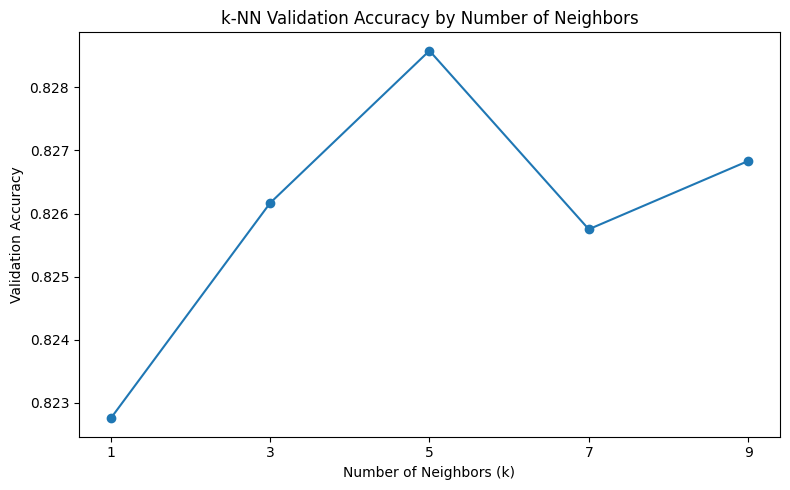

In [7]:
# ------------------------------------------------------------
# Model 2: k-Nearest Neighbors
# Owner: MEMBER_X
# ------------------------------------------------------------
#
# IMPORTANT TEMPLATE FOR ALL MODEL SECTIONS:
#
# Each model section should leave behind:
# 1. best_<model_name>_model
# 2. best_<model_name>_results
# 3. best_<model_name>_hyperparameters
# 4. <model_name>_results_df
#
# Each model section should also append its best validation result
# to the shared validation_results list using add_result().
#
# For models with hyperparameters, store all tried configurations
# in the model-specific results DataFrame, then append only the best
# configuration to validation_results.

# ------------------------------------------------------------
# Step 1: Create a smaller stratified training subset for k-NN.
# ------------------------------------------------------------
#
# k-NN can be slow because prediction compares validation examples
# against many stored training examples. To keep runtime manageable,
# we train k-NN on a stratified subset of the training set.

X_train_knn, unused_X_knn, y_train_knn, unused_y_knn = train_test_split(
    X_train,
    y_train,
    train_size=10000,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print("k-NN training subset shape:", X_train_knn.shape, y_train_knn.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)


# ------------------------------------------------------------
# Step 2: Train and evaluate k-NN for several k values.
# ------------------------------------------------------------

k_values = [1, 3, 5, 7, 9]
knn_results = []
knn_models = {}

for k in k_values:
    print("Training k-NN with k =", k)
    
    # Create classifier for this value of k.
    knn_model = KNeighborsClassifier(n_neighbors=k)
    
    # Train classifier on the smaller k-NN training subset.
    knn_model.fit(X_train_knn, y_train_knn)
    
    # Evaluate on the k-NN training subset and the full validation set.
    results = evaluate_classifier(
        knn_model,
        X_train_knn,
        y_train_knn,
        X_valid,
        y_valid
    )
    
    # Store the trained model in case it becomes the best one.
    knn_models[k] = knn_model
    
    # Store results for this value of k.
    knn_results.append({
        "model": "Model 2: k-Nearest Neighbors",
        "hyperparameters": "k=" + str(k),
        "k": k,
        "train_accuracy": results["train_accuracy"],
        "valid_accuracy": results["valid_accuracy"],
        "train_error": results["train_error"],
        "valid_error": results["valid_error"],
        "software": "scikit-learn",
        "owner": MEMBER_X
    })


# ------------------------------------------------------------
# Step 3: Convert all k-NN results to a DataFrame.
# ------------------------------------------------------------

knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)


# ------------------------------------------------------------
# Step 4: Select the best k-NN model based on validation accuracy.
# ------------------------------------------------------------

best_knn_index = knn_results_df["valid_accuracy"].idxmax()
best_knn_row = knn_results_df.loc[best_knn_index]

best_k = int(best_knn_row["k"])

best_knn_model = knn_models[best_k]

best_knn_results = {
    "train_accuracy": best_knn_row["train_accuracy"],
    "valid_accuracy": best_knn_row["valid_accuracy"],
    "train_error": best_knn_row["train_error"],
    "valid_error": best_knn_row["valid_error"]
}

best_knn_hyperparameters = "k=" + str(best_k)

print("Best k-NN hyperparameters:", best_knn_hyperparameters)
print("Best k-NN validation accuracy:", best_knn_results["valid_accuracy"])


# ------------------------------------------------------------
# Step 5: Add only the best k-NN result to validation_results.
# ------------------------------------------------------------

add_result(
    validation_results,
    model_name="Model 2: k-Nearest Neighbors",
    hyperparameters=best_knn_hyperparameters,
    results=best_knn_results,
    software="scikit-learn",
    owner=MEMBER_X
)


# ------------------------------------------------------------
# Step 6: Plot validation accuracy as a function of k.
# ------------------------------------------------------------

figure, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.plot(
    knn_results_df["k"],
    knn_results_df["valid_accuracy"],
    marker="o"
)

axes.set_title("k-NN Validation Accuracy by Number of Neighbors")
axes.set_xlabel("Number of Neighbors (k)")
axes.set_ylabel("Validation Accuracy")
axes.set_xticks(k_values)

plt.tight_layout()

# Save the figure. This overwrites the existing file if it already exists.
plt.savefig(os.path.join(FIGURES_DIR, "knn_validation_accuracy.png"), bbox_inches="tight", dpi=300)

plt.show()

#### Part 7: Summary

This section contributes to the **Classifiers**, **Experimental Setup**, and **Experimental Results** sections of the final PDF report.

For the **Classifiers** section, k-Nearest Neighbors can be described as a distance-based classifier that predicts a label by looking at the labels of the nearest training examples. The main hyperparameter investigated was the number of neighbors, with `k = 1, 3, 5, 7, 9`.

For the **Experimental Setup** section, this section documents that k-NN was trained on a smaller stratified training subset to keep runtime manageable. The model was still evaluated on the same validation set used by the other classifiers, so its validation result can still be included in the model comparison.

For the **Experimental Results** section, the table shows training and validation accuracy/error for each tested value of `k`. The saved figure `knn_validation_accuracy.png` visualizes how validation accuracy changes as the number of neighbors changes. The best k-NN configuration is stored for later use in Part 11: Model Comparison and Part 12: Final Test Evaluation.

# Part 8, Model 3: Logistic Regression

In this section, we train and evaluate **Model 3: Logistic Regression**. This is our third classifier and our strongest baseline so far. Unlike Nearest Centroid and k-Nearest Neighbors, Logistic Regression is a learned parametric model. It learns weights for the input features and uses those weights to predict which clothing class an image belongs to.

For this project, Logistic Regression is useful because it gives us a simple learned classifier that can be compared against both distance-based methods and the later nonlinear models. Since the Fashion-MNIST images are already flattened into 784 numerical pixel features, Logistic Regression can be applied directly to the data.

The main hyperparameter we investigate is `C`, which controls the strength of regularization:

- Smaller `C` means stronger regularization.
- Larger `C` means weaker regularization.

We test the following values:

- `C = 0.01`
- `C = 0.1`
- `C = 1`
- `C = 10`

To keep runtime manageable, we train Logistic Regression on a stratified subset of 20,000 training examples. This is larger than the subset used for k-NN but still smaller than the full training set. The model is evaluated on the full validation set, so its validation accuracy can still be compared with the other classifiers.

This section follows the same required structure as the previous model sections:

1. Create a stratified training subset.
2. Train Logistic Regression for several `C` values.
3. Evaluate each version on training and validation data.
4. Store all hyperparameter results in a model-specific DataFrame.
5. Select the best version based on validation accuracy.
6. Store the best model, best results, and best hyperparameters using standardized variable names.
7. Add the best Logistic Regression result to the shared `validation_results` list.
8. Create and save a model-specific figure showing validation accuracy as a function of `C`.

The test set is not used in this section. It remains reserved for final evaluation only.

Logistic Regression training subset shape: (20000, 784) (20000,)
Validation set shape: (12000, 784) (12000,)
Training Logistic Regression with C = 0.01
Training Logistic Regression with C = 0.1
Training Logistic Regression with C = 1
Training Logistic Regression with C = 10


,model,hyperparameters,C,train_accuracy,valid_accuracy,train_error,valid_error,software,owner
0,Model 3: Logistic Regression,C=0.01,0.01,0.84765,0.844667,0.15235,0.155333,scikit-learn,Jacob Peters
1,Model 3: Logistic Regression,C=0.1,0.10,0.87755,0.858250,0.12245,0.141750,scikit-learn,Jacob Peters
2,Model 3: Logistic Regression,C=1,1.00,0.89905,0.849083,0.10095,0.150917,scikit-learn,Jacob Peters
3,Model 3: Logistic Regression,C=10,10.00,0.90220,0.842417,0.09780,0.157583,scikit-learn,Jacob Peters


Best Logistic Regression hyperparameters: C=0.1
Best Logistic Regression validation accuracy: 0.85825


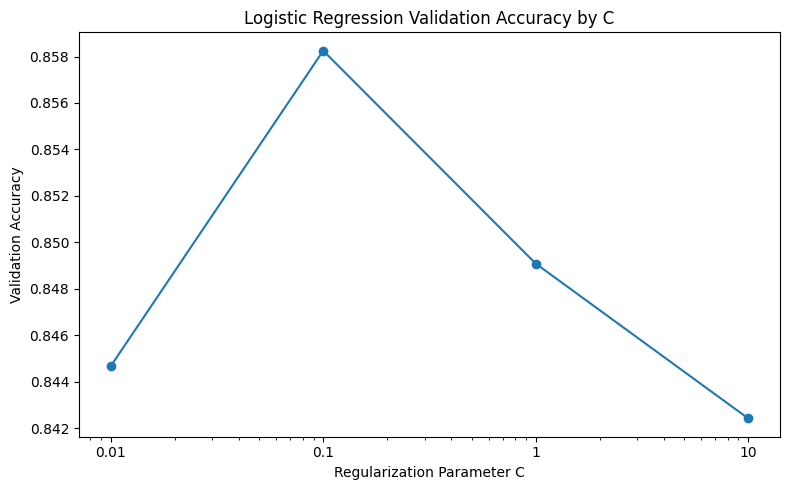

In [8]:
# ------------------------------------------------------------
# Model 3: Logistic Regression
# Owner: MEMBER_X
# ------------------------------------------------------------
#
# IMPORTANT TEMPLATE FOR ALL MODEL SECTIONS:
#
# Each model section should leave behind:
# 1. best_<model_name>_model
# 2. best_<model_name>_results
# 3. best_<model_name>_hyperparameters
# 4. <model_name>_results_df
#
# Each model section should also append its best validation result
# to the shared validation_results list using add_result().
#
# For models with hyperparameters, store all tried configurations
# in the model-specific results DataFrame, then append only the best
# configuration to validation_results.

# ------------------------------------------------------------
# Step 1: Create a smaller stratified training subset for Logistic Regression.
# ------------------------------------------------------------
#
# Logistic Regression can be slower on the full 48,000-example training set,
# so we use a 20,000-example stratified subset to keep runtime manageable.

X_train_logistic, unused_X_logistic, y_train_logistic, unused_y_logistic = train_test_split(
    X_train,
    y_train,
    train_size=20000,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print("Logistic Regression training subset shape:", X_train_logistic.shape, y_train_logistic.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)


# ------------------------------------------------------------
# Step 2: Train and evaluate Logistic Regression for several C values.
# ------------------------------------------------------------

C_values = [0.01, 0.1, 1, 10]
logistic_regression_results = []
logistic_regression_models = {}

for C in C_values:
    print("Training Logistic Regression with C =", C)
    
    # Create classifier for this value of C.
    logistic_regression_model = LogisticRegression(
        C=C,
        solver="lbfgs",
        max_iter=300,
        random_state=RANDOM_SEED
    )
    
    # Train classifier on the Logistic Regression training subset.
    logistic_regression_model.fit(X_train_logistic, y_train_logistic)
    
    # Evaluate on the Logistic Regression training subset and the full validation set.
    results = evaluate_classifier(
        logistic_regression_model,
        X_train_logistic,
        y_train_logistic,
        X_valid,
        y_valid
    )
    
    # Store the trained model in case it becomes the best one.
    logistic_regression_models[C] = logistic_regression_model
    
    # Store results for this value of C.
    logistic_regression_results.append({
        "model": "Model 3: Logistic Regression",
        "hyperparameters": "C=" + str(C),
        "C": C,
        "train_accuracy": results["train_accuracy"],
        "valid_accuracy": results["valid_accuracy"],
        "train_error": results["train_error"],
        "valid_error": results["valid_error"],
        "software": "scikit-learn",
        "owner": MEMBER_X
    })


# ------------------------------------------------------------
# Step 3: Convert all Logistic Regression results to a DataFrame.
# ------------------------------------------------------------

logistic_regression_results_df = pd.DataFrame(logistic_regression_results)

display(logistic_regression_results_df)


# ------------------------------------------------------------
# Step 4: Select the best Logistic Regression model based on validation accuracy.
# ------------------------------------------------------------

best_logistic_regression_index = logistic_regression_results_df["valid_accuracy"].idxmax()
best_logistic_regression_row = logistic_regression_results_df.loc[best_logistic_regression_index]

best_C = float(best_logistic_regression_row["C"])

best_logistic_regression_model = logistic_regression_models[best_C]

best_logistic_regression_results = {
    "train_accuracy": best_logistic_regression_row["train_accuracy"],
    "valid_accuracy": best_logistic_regression_row["valid_accuracy"],
    "train_error": best_logistic_regression_row["train_error"],
    "valid_error": best_logistic_regression_row["valid_error"]
}

best_logistic_regression_hyperparameters = "C=" + str(best_C)

print("Best Logistic Regression hyperparameters:", best_logistic_regression_hyperparameters)
print("Best Logistic Regression validation accuracy:", best_logistic_regression_results["valid_accuracy"])


# ------------------------------------------------------------
# Step 5: Add only the best Logistic Regression result to validation_results.
# ------------------------------------------------------------

add_result(
    validation_results,
    model_name="Model 3: Logistic Regression",
    hyperparameters=best_logistic_regression_hyperparameters,
    results=best_logistic_regression_results,
    software="scikit-learn",
    owner=MEMBER_X
)


# ------------------------------------------------------------
# Step 6: Plot validation accuracy as a function of C.
# ------------------------------------------------------------

figure, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.semilogx(
    logistic_regression_results_df["C"],
    logistic_regression_results_df["valid_accuracy"],
    marker="o"
)

axes.set_title("Logistic Regression Validation Accuracy by C")
axes.set_xlabel("Regularization Parameter C")
axes.set_ylabel("Validation Accuracy")
axes.set_xticks(C_values)
axes.set_xticklabels([str(C) for C in C_values])

plt.tight_layout()

# Save the figure. This overwrites the existing file if it already exists.
plt.savefig(os.path.join(FIGURES_DIR, "logistic_regression_validation_accuracy.png"), bbox_inches="tight", dpi=300)

plt.show()

#### Part 8: Summary

This section contributes to the **Classifiers**, **Experimental Setup**, and **Experimental Results** sections of the final PDF report.

For the **Classifiers** section, Logistic Regression can be described as a learned linear classifier that estimates class probabilities from the pixel features of each image. The hyperparameter investigated was the regularization parameter `C`, with values `0.01`, `0.1`, `1`, and `10`.

For the **Experimental Setup** section, this section documents that Logistic Regression was trained on a stratified 20,000-example subset to keep runtime manageable. The model was evaluated on the same validation set used by the other classifiers, and the test set was not used.

For the **Experimental Results** section, the table shows training and validation accuracy/error for each tested value of `C`. The saved figure `logistic_regression_validation_accuracy.png` visualizes how validation accuracy changes as regularization strength changes. The best Logistic Regression configuration is stored for later use in Part 11: Model Comparison and Part 12: Final Test Evaluation.

# Part 9, Model 4: Decision Tree

This section is reserved for **Member A**.

In this section, Member A will train and evaluate **Model 4: Decision Tree**. A Decision Tree is a nonlinear classifier that makes predictions by repeatedly splitting the data according to feature values. For Fashion-MNIST, the features are the 784 pixel values of each image, so the tree learns rules based on pixel intensities.

This model is included because it gives the project a nonlinear method that is different from the earlier distance-based and linear models. Unlike Logistic Regression, which uses a weighted linear combination of input features, a Decision Tree can learn branching rules and interactions between features.

Member A should investigate the following hyperparameters:

- `max_depth = [5, 10, 20, None]`
- `min_samples_leaf = [1, 5, 10]`

The goal is to train several Decision Tree models, evaluate each one on the validation set, and select the best configuration based on validation accuracy.

To keep runtime manageable, Member A should train the Decision Tree models on a stratified subset of 20,000 training examples. The models should still be evaluated on the full validation set so that the results are comparable with the other classifiers.

This section must follow the same structure as the completed model sections above. When Member A finishes this section, it must create the following variables:

- `decision_tree_results_df`
- `best_decision_tree_model`
- `best_decision_tree_results`
- `best_decision_tree_hyperparameters`

Member A must also append the best Decision Tree result to the shared `validation_results` list using the `add_result()` helper function. This is required so that Part 11: Model Comparison and Part 12: Final Test Evaluation can automatically include the Decision Tree model later.

The test set should not be used in this section.

In [9]:
# ------------------------------------------------------------
# Model 4: Decision Tree
# Owner: MEMBER_A
# ------------------------------------------------------------
#
# This section is for Member A.
# Complete the code only inside the YOUR CODE blocks.
# Do not use X_test or y_test in this section.

print("Part 9 is reserved for", MEMBER_A)
print(MEMBER_A, "should complete the Decision Tree implementation here.")

# Hyperparameter values to investigate
max_depth_values = [5, 10, 20, None]
min_samples_leaf_values = [1, 5, 10]

# Create a smaller stratified training subset for the Decision Tree model.
### YOUR CODE STARTS HERE ###

raise NotImplementedError

### YOUR CODE ENDS HERE ###

print("Decision Tree training subset shape:", X_train_tree.shape, y_train_tree.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)

# Train and evaluate Decision Tree models.
decision_tree_results = []
decision_tree_models = {}

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        
        ### YOUR CODE STARTS HERE ###
        
        raise NotImplementedError
        
        ### YOUR CODE ENDS HERE ###
        
        key = (max_depth, min_samples_leaf)
        decision_tree_models[key] = tree_model
        
        decision_tree_results.append({
            "model": "Model 4: Decision Tree",
            "hyperparameters": "max_depth=" + str(max_depth) + ", min_samples_leaf=" + str(min_samples_leaf),
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "train_accuracy": results["train_accuracy"],
            "valid_accuracy": results["valid_accuracy"],
            "train_error": results["train_error"],
            "valid_error": results["valid_error"],
            "software": "scikit-learn",
            "owner": MEMBER_A
        })

# Convert results to a DataFrame and display it.
decision_tree_results_df = pd.DataFrame(decision_tree_results)

display(decision_tree_results_df)

# Select the best Decision Tree model based on validation accuracy.
### YOUR CODE STARTS HERE ###

raise NotImplementedError

### YOUR CODE ENDS HERE ###

print("Best Decision Tree hyperparameters:", best_decision_tree_hyperparameters)
print("Best Decision Tree validation accuracy:", best_decision_tree_results["valid_accuracy"])

# Add only the best Decision Tree result to validation_results.
add_result(
    validation_results,
    model_name="Model 4: Decision Tree",
    hyperparameters=best_decision_tree_hyperparameters,
    results=best_decision_tree_results,
    software="scikit-learn",
    owner=MEMBER_A
)

# Create and save a model-specific figure.
figure, axes = plt.subplots(1, 1, figsize=(10, 5))

labels = decision_tree_results_df["hyperparameters"]

axes.bar(labels, decision_tree_results_df["valid_accuracy"])
axes.set_title("Decision Tree Validation Accuracy by Hyperparameter Setting")
axes.set_xlabel("Hyperparameter Setting")
axes.set_ylabel("Validation Accuracy")
axes.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "decision_tree_validation_accuracy.png"), bbox_inches="tight", dpi=300)
plt.show()

Part 9 is reserved for Member A
Member A should complete the Decision Tree implementation here.


NotImplementedError: 

#### Part 9: Summary

Once Member A completes this section, it will contribute to the **Classifiers**, **Experimental Setup**, and **Experimental Results** sections of the final PDF report.

For the **Classifiers** section, Decision Tree should be described as a nonlinear classifier that predicts labels by following a sequence of feature-based splitting rules. The hyperparameters investigated should include `max_depth` and `min_samples_leaf`.

For the **Experimental Setup** section, Member A should document that the Decision Tree was trained on a stratified training subset and evaluated on the validation set without using the test set.

For the **Experimental Results** section, this section should provide a table of validation results across different Decision Tree hyperparameter settings, a saved validation accuracy figure, and the best Decision Tree configuration for later comparison.

# Part 10, Model 5: MLP Classifier

This section is reserved for **Member B**.

In this section, Member B will train and evaluate **Model 5: MLP Classifier**. An MLP, or multilayer perceptron, is a neural-network classifier. Unlike Logistic Regression, which learns a linear decision boundary, an MLP can learn nonlinear relationships between the 784 pixel features and the 10 Fashion-MNIST classes.

This model is included because it gives the project a more flexible classifier than the previous models while still staying within the same scikit-learn workflow used throughout the notebook. We use `MLPClassifier` instead of a PyTorch or TensorFlow neural network so the project remains consistent with the previous CS 178 homework style.

Member B should investigate the following hyperparameters:

- `hidden_layer_sizes = [(64,), (128,), (128, 64)]`
- `alpha = [0.0001, 0.001]`

The `hidden_layer_sizes` parameter controls the number and size of hidden layers in the neural network. The `alpha` parameter controls L2 regularization strength. Testing several combinations of these values gives a manageable hyperparameter search while still satisfying the project requirement to investigate different model settings.

To keep runtime manageable, Member B should train the MLP models on a stratified subset of 20,000 training examples. The models should still be evaluated on the full validation set so that the results are comparable with the other classifiers.

When Member B completes this section, it must create the following variables:

- `mlp_results_df`
- `best_mlp_model`
- `best_mlp_results`
- `best_mlp_hyperparameters`

Member B must also append the best MLP result to the shared `validation_results` list using the `add_result()` helper function. This is required so that Part 11: Model Comparison and Part 12: Final Test Evaluation can automatically include the MLP model later.

The test set should not be used in this section.

In [10]:
# ------------------------------------------------------------
# Model 5: MLP Classifier
# Owner: MEMBER_B
# ------------------------------------------------------------
#
# This section is for Member B.
# Complete the code only inside the YOUR CODE blocks.
# Do not use X_test or y_test in this section.

print("Part 10 is reserved for", MEMBER_B)
print(MEMBER_B, "should complete the MLP Classifier implementation here.")

# Hyperparameter values to investigate
hidden_layer_sizes_values = [(64,), (128,), (128, 64)]
alpha_values = [0.0001, 0.001]

# Create a smaller stratified training subset for the MLP Classifier.
### YOUR CODE STARTS HERE ###

raise NotImplementedError

### YOUR CODE ENDS HERE ###

print("MLP training subset shape:", X_train_mlp.shape, y_train_mlp.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)

# Train and evaluate MLP models.
mlp_results = []
mlp_models = {}

for hidden_layer_sizes in hidden_layer_sizes_values:
    for alpha in alpha_values:
        
        ### YOUR CODE STARTS HERE ###
        
        raise NotImplementedError
        
        ### YOUR CODE ENDS HERE ###
        
        key = (hidden_layer_sizes, alpha)
        mlp_models[key] = mlp_model
        
        mlp_results.append({
            "model": "Model 5: MLP Classifier",
            "hyperparameters": "hidden_layer_sizes=" + str(hidden_layer_sizes) + ", alpha=" + str(alpha),
            "hidden_layer_sizes": hidden_layer_sizes,
            "alpha": alpha,
            "train_accuracy": results["train_accuracy"],
            "valid_accuracy": results["valid_accuracy"],
            "train_error": results["train_error"],
            "valid_error": results["valid_error"],
            "software": "scikit-learn",
            "owner": MEMBER_B
        })

# Convert results to a DataFrame and display it.
mlp_results_df = pd.DataFrame(mlp_results)

display(mlp_results_df)

# Select the best MLP model based on validation accuracy.
### YOUR CODE STARTS HERE ###

raise NotImplementedError

### YOUR CODE ENDS HERE ###

print("Best MLP hyperparameters:", best_mlp_hyperparameters)
print("Best MLP validation accuracy:", best_mlp_results["valid_accuracy"])

# Add only the best MLP result to validation_results.
add_result(
    validation_results,
    model_name="Model 5: MLP Classifier",
    hyperparameters=best_mlp_hyperparameters,
    results=best_mlp_results,
    software="scikit-learn",
    owner=MEMBER_B
)

# Create and save a model-specific figure.
figure, axes = plt.subplots(1, 1, figsize=(10, 5))

labels = mlp_results_df["hyperparameters"]

axes.bar(labels, mlp_results_df["valid_accuracy"])
axes.set_title("MLP Validation Accuracy by Hyperparameter Setting")
axes.set_xlabel("Hyperparameter Setting")
axes.set_ylabel("Validation Accuracy")
axes.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "mlp_validation_accuracy.png"), bbox_inches="tight", dpi=300)
plt.show()

Part 10 is reserved for Member B
Member B should complete the MLP Classifier implementation here.


NotImplementedError: 

#### Part 10: Summary

Once Member B completes this section, it will contribute to the **Classifiers**, **Experimental Setup**, and **Experimental Results** sections of the final PDF report.

For the **Classifiers** section, MLP Classifier should be described as a neural-network classifier that learns nonlinear relationships between the pixel features and the clothing labels. The hyperparameters investigated should include `hidden_layer_sizes` and `alpha`.

For the **Experimental Setup** section, Member B should document that the MLP was trained on a stratified training subset and evaluated on the validation set without using the test set. The use of `early_stopping=True` should also be mentioned if Member B uses the recommended `MLPClassifier` settings.

For the **Experimental Results** section, this section should provide a table of validation results across different MLP hyperparameter settings, a saved validation accuracy figure, and the best MLP configuration for later comparison.

# Part 11: Model Comparison

In this section, we compare the completed models using validation-set results. This section is intentionally written to be modular: it will work even if only some models have been completed. At this stage, Models 1, 2, and 3 should already be complete, while Models 4 and 5 may still be unfinished until Member A and Member B complete their sections.

The comparison uses the shared `validation_results` list. Each completed model section appends its best validation result to this list using the `add_result()` helper function. Because of that structure, this section can automatically include whichever models are currently complete.

This section does **not** use the test set. The purpose here is validation-based model comparison and selection. The test set remains reserved for Part 12: Final Test Evaluation.

This section will:

1. Convert `validation_results` into a pandas DataFrame.
2. Check whether any model results are available.
3. Sort completed models by validation accuracy.
4. Display a validation comparison table.
5. Create and save a validation accuracy comparison figure.
6. Identify the best currently available model based on validation accuracy.

The output from this section helps decide which model configurations should move forward to final test evaluation.

Completed models included in validation comparison:


,model,hyperparameters,train_accuracy,valid_accuracy,train_error,valid_error,software,owner,short_model
0,Model 3: Logistic Regression,C=0.1,0.877550,0.858250,0.122450,0.141750,scikit-learn,Jacob Peters,Logistic Regression
1,Model 2: k-Nearest Neighbors,k=5,0.877100,0.828583,0.122900,0.171417,scikit-learn,Jacob Peters,k-Nearest Neighbors
2,Model 1: Nearest Centroid,none,0.684438,0.690917,0.315562,0.309083,scikit-learn,Jacob Peters,Nearest Centroid


Best validation model: Model 3: Logistic Regression
Best validation hyperparameters: C=0.1
Best validation accuracy: 0.85825
Best validation error: 0.14175000000000004


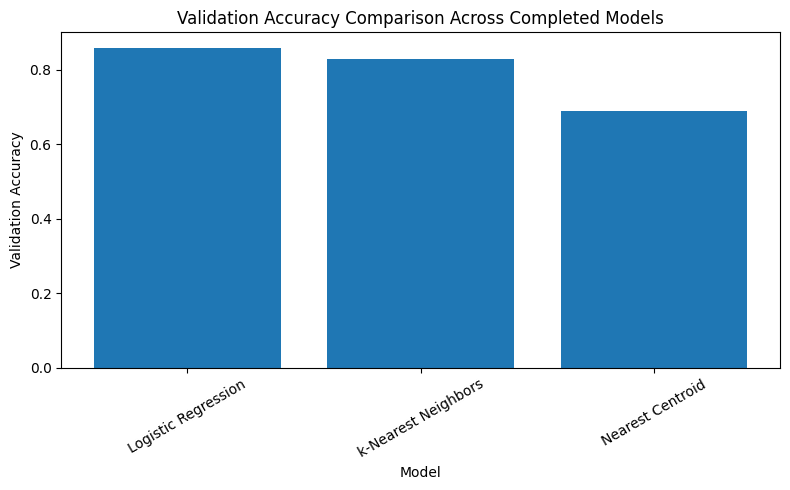

In [11]:
# ------------------------------------------------------------
# Part 11: Model Comparison
# ------------------------------------------------------------
#
# This section compares completed models using validation results only.
# It does not use X_test or y_test.
#
# The code is written to work even if Models 4 and 5 are not complete yet.
# Once Members A and B complete their sections, their models will be included
# automatically as long as they append their best result to validation_results.

if len(validation_results) == 0:
    print("No validation results found.")
    print("Complete at least one model section before running Part 11.")
    
else:
    # Convert the shared results list into a DataFrame.
    validation_results_df = pd.DataFrame(validation_results)
    
    # Sort models from highest validation accuracy to lowest.
    best_validation_models_df = validation_results_df.sort_values(
        by="valid_accuracy",
        ascending=False
    ).reset_index(drop=True)
    
    # Create shorter model names for cleaner tables and figures.
    short_model_names = {
        "Model 1: Nearest Centroid": "Nearest Centroid",
        "Model 2: k-Nearest Neighbors": "k-Nearest Neighbors",
        "Model 3: Logistic Regression": "Logistic Regression",
        "Model 4: Decision Tree": "Decision Tree",
        "Model 5: MLP Classifier": "MLP Classifier"
    }
    
    best_validation_models_df["short_model"] = best_validation_models_df["model"].replace(short_model_names)
    
    # Display completed model comparison.
    print("Completed models included in validation comparison:")
    display(best_validation_models_df)
    
    # Identify the best currently available model based on validation accuracy.
    best_validation_row = best_validation_models_df.iloc[0]
    
    best_validation_model_name = best_validation_row["model"]
    best_validation_model_hyperparameters = best_validation_row["hyperparameters"]
    best_validation_accuracy = best_validation_row["valid_accuracy"]
    best_validation_error = best_validation_row["valid_error"]
    
    print("Best validation model:", best_validation_model_name)
    print("Best validation hyperparameters:", best_validation_model_hyperparameters)
    print("Best validation accuracy:", best_validation_accuracy)
    print("Best validation error:", best_validation_error)
    
    # Create a validation accuracy comparison figure.
    figure, axes = plt.subplots(1, 1, figsize=(8, 5))
    
    axes.bar(
        best_validation_models_df["short_model"],
        best_validation_models_df["valid_accuracy"]
    )
    
    axes.set_title("Validation Accuracy Comparison Across Completed Models")
    axes.set_xlabel("Model")
    axes.set_ylabel("Validation Accuracy")
    axes.tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    
    # Save the figure. This overwrites the existing file if it already exists.
    plt.savefig(
        os.path.join(FIGURES_DIR, "model_validation_comparison.png"),
        bbox_inches="tight",
        dpi=300
    )
    
    plt.show()

#### Part 11: Summary

This section contributes directly to the **Experimental Results** section of the final PDF report. It produces a validation results table and a validation accuracy comparison figure for all completed models.

The comparison uses validation performance only, which keeps the final test set untouched until the next section. This supports a correct experimental workflow: models and hyperparameters are selected using validation data, and final test data is reserved for the final evaluation.

The saved figure `model_validation_comparison.png` can be used in the final report to show how the completed models compare before final test evaluation.

# Part 12: Final Test Evaluation

In this section, we evaluate the selected models on the final held-out test set. This is the first section where the test set should be used. All previous model training, hyperparameter tuning, and model comparison were based on the training and validation sets only.

The purpose of this section is to measure how well the selected models generalize to unseen data. The validation set was used to choose the best version of each model family. The test set is now used once to produce the final performance results for the project.

This section is written to be modular. It checks which best-model variables currently exist and evaluates only those models. At this point, Models 1, 2, and 3 should already be complete. Models 4 and 5 will be included automatically later if Member A and Member B complete their sections using the required variable names.

This section will:

1. Check which completed best-model variables are available.
2. Evaluate each completed model on `X_test` and `y_test`.
3. Compute test accuracy and test error.
4. Store final test results in a table called `test_results_df`.
5. Identify the best model based on test accuracy.
6. Create and save a final test accuracy comparison figure.

This section should not be used to tune hyperparameters or change model choices. The goal is final evaluation only.

Evaluating Model 1: Nearest Centroid on the final test set.
Evaluating Model 2: k-Nearest Neighbors on the final test set.
Evaluating Model 3: Logistic Regression on the final test set.
Final test results for completed models:


,model,short_model,hyperparameters,test_accuracy,test_error
0,Model 3: Logistic Regression,Logistic Regression,C=0.1,0.8393,0.1607
1,Model 2: k-Nearest Neighbors,k-Nearest Neighbors,k=5,0.8163,0.1837
2,Model 1: Nearest Centroid,Nearest Centroid,none,0.6771,0.3229


Best test model: Model 3: Logistic Regression
Best test hyperparameters: C=0.1
Best test accuracy: 0.8393
Best test error: 0.16069999999999995


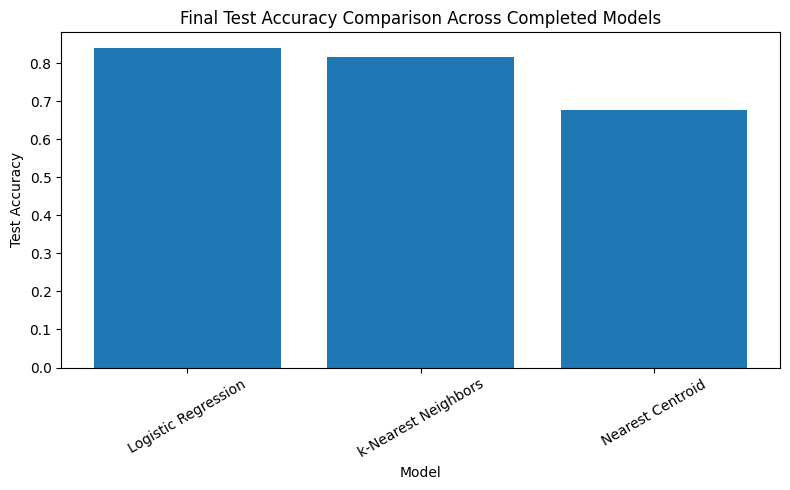

In [12]:
# ------------------------------------------------------------
# Part 12: Final Test Evaluation
# ------------------------------------------------------------
#
# This section evaluates completed best models on the final test set.
# This is the first section where X_test and y_test should be used.
#
# The code is written to work even if Models 4 and 5 are not complete yet.
# Once Members A and B complete their sections, their models will be included
# automatically as long as they create the required best model variables.

test_model_candidates = []

# Model 1: Nearest Centroid
if "best_nearest_centroid_model" in globals():
    test_model_candidates.append({
        "model": "Model 1: Nearest Centroid",
        "short_model": "Nearest Centroid",
        "hyperparameters": best_nearest_centroid_hyperparameters,
        "model_object": best_nearest_centroid_model
    })

# Model 2: k-Nearest Neighbors
if "best_knn_model" in globals():
    test_model_candidates.append({
        "model": "Model 2: k-Nearest Neighbors",
        "short_model": "k-Nearest Neighbors",
        "hyperparameters": best_knn_hyperparameters,
        "model_object": best_knn_model
    })

# Model 3: Logistic Regression
if "best_logistic_regression_model" in globals():
    test_model_candidates.append({
        "model": "Model 3: Logistic Regression",
        "short_model": "Logistic Regression",
        "hyperparameters": best_logistic_regression_hyperparameters,
        "model_object": best_logistic_regression_model
    })

# Model 4: Decision Tree
if "best_decision_tree_model" in globals():
    test_model_candidates.append({
        "model": "Model 4: Decision Tree",
        "short_model": "Decision Tree",
        "hyperparameters": best_decision_tree_hyperparameters,
        "model_object": best_decision_tree_model
    })

# Model 5: MLP Classifier
if "best_mlp_model" in globals():
    test_model_candidates.append({
        "model": "Model 5: MLP Classifier",
        "short_model": "MLP Classifier",
        "hyperparameters": best_mlp_hyperparameters,
        "model_object": best_mlp_model
    })

if len(test_model_candidates) == 0:
    print("No completed best model variables found.")
    print("Complete at least one model section before running Part 12.")
    
else:
    test_results = []
    test_predictions_by_model = {}
    
    for candidate in test_model_candidates:
        print("Evaluating", candidate["model"], "on the final test set.")
        
        model_object = candidate["model_object"]
        test_predictions = model_object.predict(X_test)
        
        test_accuracy = compute_accuracy(y_test, test_predictions)
        test_error = compute_error_rate(y_test, test_predictions)
        
        test_predictions_by_model[candidate["model"]] = test_predictions
        
        test_results.append({
            "model": candidate["model"],
            "short_model": candidate["short_model"],
            "hyperparameters": candidate["hyperparameters"],
            "test_accuracy": test_accuracy,
            "test_error": test_error
        })
    
    # Convert test results to a DataFrame and sort by test accuracy.
    test_results_df = pd.DataFrame(test_results)
    
    test_results_df = test_results_df.sort_values(
        by="test_accuracy",
        ascending=False
    ).reset_index(drop=True)
    
    print("Final test results for completed models:")
    display(test_results_df)
    
    # Identify the best model based on final test accuracy.
    best_test_row = test_results_df.iloc[0]
    
    best_test_model_name = best_test_row["model"]
    best_test_short_model_name = best_test_row["short_model"]
    best_test_model_hyperparameters = best_test_row["hyperparameters"]
    best_test_accuracy = best_test_row["test_accuracy"]
    best_test_error = best_test_row["test_error"]
    
    best_test_model = None
    best_test_predictions = None
    
    for candidate in test_model_candidates:
        if candidate["model"] == best_test_model_name:
            best_test_model = candidate["model_object"]
            best_test_predictions = test_predictions_by_model[candidate["model"]]
    
    print("Best test model:", best_test_model_name)
    print("Best test hyperparameters:", best_test_model_hyperparameters)
    print("Best test accuracy:", best_test_accuracy)
    print("Best test error:", best_test_error)
    
    # Create a final test accuracy comparison figure.
    figure, axes = plt.subplots(1, 1, figsize=(8, 5))
    
    axes.bar(
        test_results_df["short_model"],
        test_results_df["test_accuracy"]
    )
    
    axes.set_title("Final Test Accuracy Comparison Across Completed Models")
    axes.set_xlabel("Model")
    axes.set_ylabel("Test Accuracy")
    axes.tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    
    # Save the figure. This overwrites the existing file if it already exists.
    plt.savefig(
        os.path.join(FIGURES_DIR, "final_test_accuracy_comparison.png"),
        bbox_inches="tight",
        dpi=300
    )
    
    plt.show()

#### Part 12: Summary

This section contributes directly to the **Experimental Results** section of the final PDF report. It provides the final test accuracy and test error for each completed model after model selection was performed using validation data.

The table `test_results_df` gives the final numerical performance results, while the saved figure `final_test_accuracy_comparison.png` provides a visual comparison of test accuracy across completed models. These results should be used as the main final performance evidence in the report.

This section also identifies the best model on the final test set and stores its predictions for the next section. Part 13 will use those predictions to create a confusion matrix and error analysis, which will support the report’s **Insights** section.

# Part 13: Confusion Matrix and Error Analysis

In this section, we analyze the mistakes made by the best final test model from Part 12. While Part 12 reports overall test accuracy and test error, those values do not explain which classes are difficult for the model or what kinds of mistakes the model makes. This section provides that deeper error analysis.

This section uses the best model selected during final test evaluation:

- `best_test_model`
- `best_test_model_name`
- `best_test_predictions`

The code is written dynamically, so if Models 4 and 5 are completed later and one of them becomes the best final test model, this section will analyze that new best model after Parts 11 and 12 are rerun.

This section creates several outputs:

1. A confusion matrix for the best test model.
2. A classification report showing precision, recall, F1-score, and support for each class.
3. A table of the most common class confusions.
4. A grid of misclassified test images showing true and predicted labels.
5. A short printed summary of the most important error-analysis findings.

These outputs are important for the final report because they help explain not only which model performed best, but also where the model struggled.

Analyzing best final test model: Model 3: Logistic Regression
Best test accuracy: 0.8393
Best test error: 0.16069999999999995


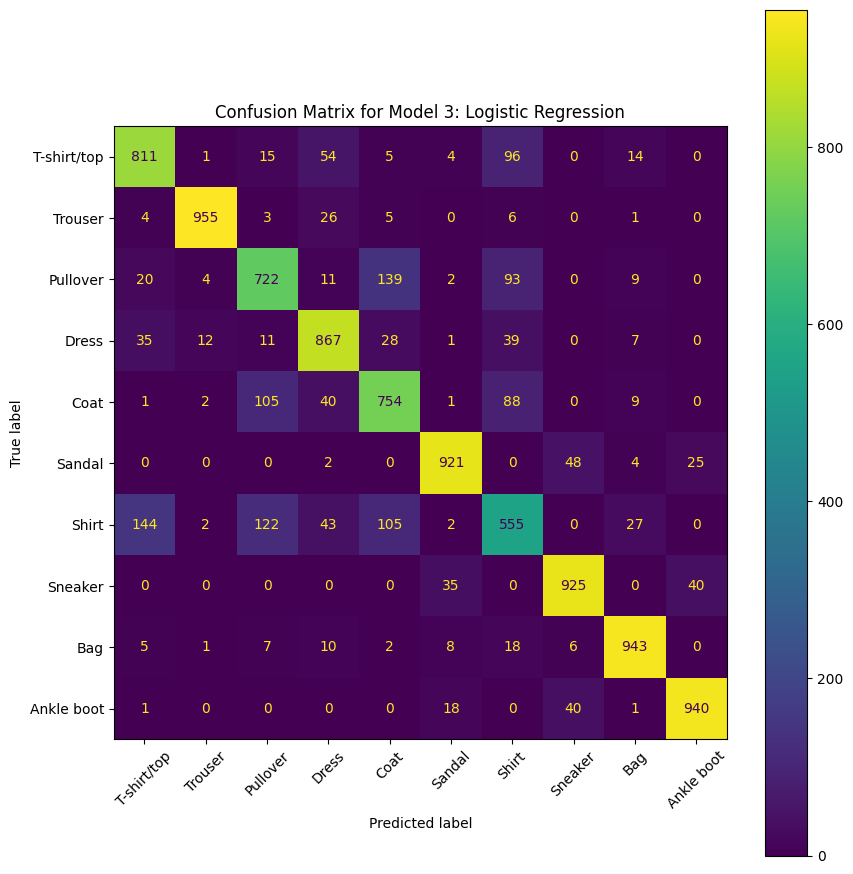

Classification report for best final test model:


,precision,recall,f1-score,support
T-shirt/top,0.794319,0.8110,0.802573,1000.0000
Trouser,0.977482,0.9550,0.966110,1000.0000
Pullover,0.732995,0.7220,0.727456,1000.0000
Dress,0.823362,0.8670,0.844618,1000.0000
Coat,0.726397,0.7540,0.739941,1000.0000
Sandal,0.928427,0.9210,0.924699,1000.0000
Shirt,0.620112,0.5550,0.585752,1000.0000
Sneaker,0.907753,0.9250,0.916295,1000.0000
Bag,0.929064,0.9430,0.935980,1000.0000
Ankle boot,0.935323,0.9400,0.937656,1000.0000


Most common class confusions:


,true_label,true_class,predicted_label,predicted_class,count
0,6,Shirt,0,T-shirt/top,144
1,2,Pullover,4,Coat,139
2,6,Shirt,2,Pullover,122
3,6,Shirt,4,Coat,105
4,4,Coat,2,Pullover,105
5,0,T-shirt/top,6,Shirt,96
6,2,Pullover,6,Shirt,93
7,4,Coat,6,Shirt,88
8,0,T-shirt/top,3,Dress,54
9,5,Sandal,7,Sneaker,48


Number of misclassified test examples: 1607


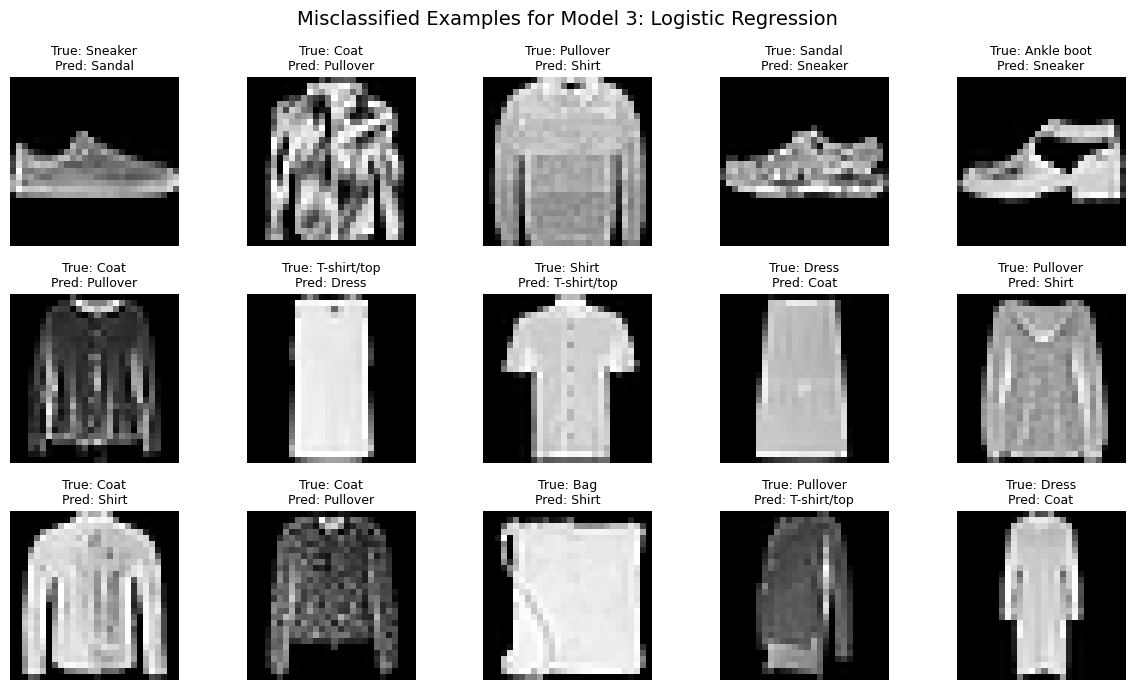

Error analysis summary:
The most common confusion was true class 'Shirt' predicted as 'T-shirt/top' with 144 test examples.
Part 13 error analysis complete.


In [13]:
# ------------------------------------------------------------
# Part 13: Confusion Matrix and Error Analysis
# ------------------------------------------------------------
#
# This section analyzes the best final test model from Part 12.
# Run Part 12 before running this section.

required_part_13_variables = [
    "best_test_model",
    "best_test_model_name",
    "best_test_predictions"
]

missing_variables = []

for variable_name in required_part_13_variables:
    if variable_name not in globals():
        missing_variables.append(variable_name)

if len(missing_variables) > 0:
    print("Part 13 cannot run yet.")
    print("Run Part 12 before running this section.")
    print("Missing variables:", missing_variables)

else:
    print("Analyzing best final test model:", best_test_model_name)
    print("Best test accuracy:", best_test_accuracy)
    print("Best test error:", best_test_error)

    # ------------------------------------------------------------
    # Step 1: Create and display the confusion matrix.
    # ------------------------------------------------------------

    best_model_confusion_matrix = confusion_matrix(y_test, best_test_predictions)

    figure, axes = plt.subplots(1, 1, figsize=(9, 9))

    confusion_display = ConfusionMatrixDisplay(
        confusion_matrix=best_model_confusion_matrix,
        display_labels=class_names
    )

    confusion_display.plot(
        ax=axes,
        xticks_rotation=45,
        values_format="d"
    )

    axes.set_title("Confusion Matrix for " + best_test_model_name)

    plt.tight_layout()

    plt.savefig(
        os.path.join(FIGURES_DIR, "best_model_confusion_matrix.png"),
        bbox_inches="tight",
        dpi=300
    )

    plt.show()

    # ------------------------------------------------------------
    # Step 2: Create a classification report.
    # ------------------------------------------------------------

    classification_report_dict = classification_report(
        y_test,
        best_test_predictions,
        target_names=class_names,
        output_dict=True
    )

    classification_report_df = pd.DataFrame(classification_report_dict).transpose()

    print("Classification report for best final test model:")
    display(classification_report_df)

    # ------------------------------------------------------------
    # Step 3: Identify the most common class confusions.
    # ------------------------------------------------------------

    confusion_pairs = []

    for true_label in range(len(class_names)):
        for predicted_label in range(len(class_names)):
            if true_label != predicted_label:
                confusion_pairs.append({
                    "true_label": true_label,
                    "true_class": class_names[true_label],
                    "predicted_label": predicted_label,
                    "predicted_class": class_names[predicted_label],
                    "count": best_model_confusion_matrix[true_label, predicted_label]
                })

    confusion_pairs_df = pd.DataFrame(confusion_pairs)

    most_confused_pairs_df = confusion_pairs_df.sort_values(
        by="count",
        ascending=False
    ).reset_index(drop=True)

    most_confused_pairs_df = most_confused_pairs_df.head(10)

    print("Most common class confusions:")
    display(most_confused_pairs_df)

    # ------------------------------------------------------------
    # Step 4: Display misclassified examples.
    # ------------------------------------------------------------

    incorrect_indices = np.where(y_test != best_test_predictions)[0]

    print("Number of misclassified test examples:", len(incorrect_indices))

    num_examples_to_show = min(15, len(incorrect_indices))

    if num_examples_to_show == 0:
        print("No misclassified examples to display.")

    else:
        figure, axes = plt.subplots(3, 5, figsize=(12, 7))
        figure.suptitle("Misclassified Examples for " + best_test_model_name, fontsize=14)

        for i in range(15):
            row = i // 5
            col = i % 5
            axes[row, col].axis("off")

        for i in range(num_examples_to_show):
            index = incorrect_indices[i]

            image = X_test[index].reshape(28, 28)
            true_class = class_names[y_test[index]]
            predicted_class = class_names[best_test_predictions[index]]

            row = i // 5
            col = i % 5

            axes[row, col].imshow(image)
            axes[row, col].set_title(
                "True: " + true_class + "\nPred: " + predicted_class,
                fontsize=9
            )
            axes[row, col].axis("off")

        plt.tight_layout()

        plt.savefig(
            os.path.join(FIGURES_DIR, "best_model_misclassified_examples.png"),
            bbox_inches="tight",
            dpi=300
        )

        plt.show()

    # ------------------------------------------------------------
    # Step 5: Print short error-analysis summary.
    # ------------------------------------------------------------

    if len(most_confused_pairs_df) > 0:
        top_confusion = most_confused_pairs_df.iloc[0]

        print("Error analysis summary:")
        print(
            "The most common confusion was true class",
            "'" + top_confusion["true_class"] + "'",
            "predicted as",
            "'" + top_confusion["predicted_class"] + "'",
            "with",
            int(top_confusion["count"]),
            "test examples."
        )

    print("Part 13 error analysis complete.")

#### Part 13: Summary

This section contributes directly to the **Insights** section of the final PDF report. The confusion matrix shows which classes the best final model predicts correctly and which classes it confuses most often. The classification report gives per-class precision, recall, and F1-score, which provides more detail than overall accuracy alone.

The most-confused-pairs table helps identify the largest sources of error, while the misclassified image grid gives qualitative examples of mistakes made by the model. These outputs can be used to discuss why certain Fashion-MNIST classes are harder to distinguish, especially when clothing categories have similar shapes or textures.

The saved figures `best_model_confusion_matrix.png` and `best_model_misclassified_examples.png` can be inserted into the final PDF report as evidence for the project’s error analysis and conclusions.

# Part 14: Report Notes

This section is reserved for **Member C**, where it describes how to turn the notebook outputs into the final PDF report. No code is needed here.

The final report should use this required section order:

1. Summary
2. Data Description
3. Classifiers
4. Experimental Setup
5. Experimental Results
6. Insights
7. Contributions

## 1. Summary

Briefly state that this project compares classifiers on Fashion-MNIST, a 10-class image classification dataset. Mention that models are selected using validation accuracy and finally evaluated on the held-out test set.

Use `test_results_df` to report the best final model.

## 2. Data Description

Use outputs from Parts 2 and 3.

Key facts:

- Fashion-MNIST has 70,000 total examples.
- Each image is 28 x 28 pixels, flattened into 784 features.
- There are 10 clothing classes.
- Pixel values were scaled to the range 0 to 1.
- The dataset is balanced across classes.

Use:

- `class_distribution`
- `figures/sample_images.png`
- `figures/class_distribution.png`

## 3. Classifiers

Describe each model and its hyperparameters.

Models:

- Nearest Centroid: no hyperparameters.
- k-Nearest Neighbors: `k = 1, 3, 5, 7, 9`.
- Logistic Regression: `C = 0.01, 0.1, 1, 10`.
- Decision Tree: `max_depth` and `min_samples_leaf`, after Member A completes Part 9.
- MLP Classifier: `hidden_layer_sizes` and `alpha`, after Member B completes Part 10.

Use:

- `nearest_centroid_results_df`
- `knn_results_df`
- `logistic_regression_results_df`
- `decision_tree_results_df`, if completed
- `mlp_results_df`, if completed

## 4. Experimental Setup

Use outputs from Parts 4 and 5.

Key facts:

- Training set: 48,000 examples.
- Validation set: 12,000 examples.
- Test set: 10,000 examples.
- Random seed: 42.
- Stratified splitting was used.
- Validation data was used for model selection.
- Test data was used only for final evaluation.
- Main metrics: accuracy and error rate.

Use:

- `split_summary`
- `split_class_distribution`

## 5. Experimental Results

Use outputs from Parts 11 and 12.

Validation comparison:

- `best_validation_models_df`
- `figures/model_validation_comparison.png`

Final test comparison:

- `test_results_df`
- `figures/final_test_accuracy_comparison.png`

The final test results should be the main evidence for which model performed best.

After Members A and B complete Parts 9 and 10, rerun Parts 11 and 12 before finalizing this section.

## 6. Insights

Use outputs from Part 13.

Use:

- `classification_report_df`
- `most_confused_pairs_df`
- `figures/best_model_confusion_matrix.png`
- `figures/best_model_misclassified_examples.png`

Discuss:

- Which model performed best.
- Which classes were most often confused.
- Whether those mistakes make visual sense.
- What limitations come from using flattened pixel features.

## 7. Contributions

Suggested contribution notes:

- Jacob Peters: setup, data loading, EDA, splitting, helper functions, Models 1–3, model comparison, final test evaluation, and error analysis.
- Member A: Decision Tree model and results.
- Member B: MLP Classifier model and results.
- Member C: final PDF assembly, summary, insights, and final editing.

Update with real names and final work completed.

## Generated figure checklist

Use these figures where appropriate:

- `figures/sample_images.png` — sample images for Data Description.
- `figures/class_distribution.png` — class balance for Data Description.
- `figures/knn_validation_accuracy.png` — k-NN tuning.
- `figures/logistic_regression_validation_accuracy.png` — Logistic Regression tuning.
- `figures/decision_tree_validation_accuracy.png` — Decision Tree tuning, if completed.
- `figures/mlp_validation_accuracy.png` — MLP tuning, if completed.
- `figures/model_validation_comparison.png` — validation model comparison.
- `figures/final_test_accuracy_comparison.png` — final test comparison.
- `figures/best_model_confusion_matrix.png` — error analysis.
- `figures/best_model_misclassified_examples.png` — qualitative error examples.

## Final checklist

Before submitting:

1. Complete Parts 9 and 10.
2. Rerun the notebook from the top.
3. Confirm Parts 11, 12, and 13 include all completed models.
4. Insert the most important tables and figures into the PDF.
5. Keep the report concise and organized using the required section order.